<a href="https://colab.research.google.com/github/VInitha24057/Ai-Hallucination-/blob/main/Ai_Hallucination_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

df = pd.read_csv('/content/ai_hallucination_dataset.csv')

df.head()

,response_id,prompt_category,prompt_text,prompt_word_count,prompt_complexity_score,response_text,response_word_count,model_version,temperature,confidence_score,...,citation_count,numeric_claims_count,contains_future_date_reference,named_entity_count,response_time_ms,user_feedback_rating,flagged_by_user,hallucination_risk_probability,hallucinated,risk_level
0,RESP_00481,Healthcare Documentation,Summarize the documentation requirements for d...,7,2,It is well established that the typical dosage...,25,XYZ-Core-v1,0.93,87,...,0,3,0,1,381,3.0,1,0.7704,1,High
1,RESP_00613,Customer Support,Can you explain the warranty terms for CloudDesk?,8,4,"Generally speaking, the standard processing wi...",21,XYZ-Core-v1,0.34,53,...,0,0,1,3,1071,2.0,0,0.5652,1,Medium
2,RESP_01364,Enterprise Knowledge Search,What changed in our vendor onboarding process ...,9,4,"Without a doubt, the policy was last revised i...",10,XYZ-Pro-v3,0.42,77,...,0,0,1,1,515,5.0,0,0.5538,0,Medium
3,RESP_00222,Healthcare Documentation,Summarize the standard treatment guidelines fo...,9,6,"Based on available records, the typical dosage...",29,XYZ-Core-v1,0.64,82,...,0,2,0,0,1033,1.0,0,0.3960,1,Medium
4,RESP_00727,Customer Support,Why is my NovaCRM subscription showing an inco...,10,5,"Generally speaking, the standard processing wi...",22,XYZ-Pro-v3,0.85,60,...,3,0,1,1,861,3.0,0,0.1798,0,Low


In [ ]:
df.shape



(1818, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1818 entries, 0 to 1817
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   response_id                     1818 non-null   object 
 1   prompt_category                 1818 non-null   object 
 2   prompt_text                     1818 non-null   object 
 3   prompt_word_count               1818 non-null   int64  
 4   prompt_complexity_score         1818 non-null   int64  
 5   response_text                   1818 non-null   object 
 6   response_word_count             1818 non-null   int64  
 7   model_version                   1791 non-null   object 
 8   temperature                     1818 non-null   float64
 9   confidence_score                1818 non-null   int64  
 10  has_citation                    1818 non-null   int64  
 11  citation_count                  1818 non-null   int64  
 12  numeric_claims_count            18

In [10]:
df.describe()

,prompt_word_count,prompt_complexity_score,response_word_count,temperature,confidence_score,has_citation,citation_count,numeric_claims_count,contains_future_date_reference,named_entity_count,response_time_ms,user_feedback_rating,flagged_by_user,hallucination_risk_probability,hallucinated
count,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000,1692.000000,1818.000000,1818.000000,1818.000000
mean,9.030803,4.539054,18.639164,0.593707,74.398240,0.428493,0.858636,1.069857,0.356986,2.045105,923.254125,3.378251,0.186469,0.435570,0.429043
std,1.445064,1.575075,7.298996,0.250177,14.477958,0.494996,1.129645,1.079179,0.479242,1.456827,936.744245,1.251828,0.389592,0.271267,0.495076
min,6.000000,2.000000,6.000000,0.000000,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,120.000000,1.000000,0.000000,0.007300,0.000000
25%,8.000000,3.000000,13.000000,0.420000,65.000000,0.000000,0.000000,0.000000,0.000000,1.000000,654.250000,2.000000,0.000000,0.195225,0.000000
50%,9.000000,4.000000,19.000000,0.600000,75.000000,0.000000,0.000000,1.000000,0.000000,2.000000,852.000000,3.000000,0.000000,0.408250,0.000000
75%,10.000000,6.000000,23.000000,0.760000,85.000000,1.000000,2.000000,2.000000,1.000000,3.000000,1070.250000,4.000000,0.000000,0.663325,1.000000
max,12.000000,10.000000,53.000000,1.200000,99.000000,1.000000,3.000000,6.000000,1.000000,8.000000,14608.000000,5.000000,1.000000,0.988700,1.000000


In [11]:
df.isnull().sum()

,0
response_id,0
prompt_category,0
prompt_text,0
prompt_word_count,0
prompt_complexity_score,0
response_text,0
response_word_count,0
model_version,27
temperature,0
confidence_score,0


In [14]:
dup=df.drop_duplicates(inplace=True)
print(dup)

None


In [20]:
df['model_version'].fillna(df['model_version'].mode()[0],inplace=True)
df['user_feedback_rating'].fillna(df['user_feedback_rating'].median(),
    inplace=True)


/tmp/ipykernel_1577/383518218.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['model_version'].fillna(df['model_version'].mode()[0],inplace=True)
/tmp/ipykernel_1577/383518218.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [21]:
df['hallucinated'].value_counts()

,count
hallucinated,
0,1024
1,776


In [32]:
risk = df.groupby(
    'prompt_category'
)['hallucinated'].mean()*100

risk.sort_values(
    ascending=False
)

,hallucinated
prompt_category,
healthcare documentation,66.666667
financial analysis,64.705882
enterprise knowledge search,62.500000
Financial Analysis,51.104972
Healthcare Documentation,49.666667
Legal Research,46.289753
customer support,42.857143
Enterprise Knowledge Search,41.355932
legal research,33.333333


In [33]:
df.groupby(
    'prompt_complexity_score'
)['hallucinated'].mean()


,hallucinated
prompt_complexity_score,
2,0.448980
3,0.369338
4,0.424821
5,0.430288
6,0.475862
7,0.382812
8,0.560000
9,0.727273
10,0.666667


In [34]:
df.groupby(
pd.cut(
df['response_word_count'],
bins=[0,100,300,1000]
)
)['hallucinated'].mean()

/tmp/ipykernel_1577/890784239.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


,hallucinated
response_word_count,
"(0, 100]",0.431111
"(100, 300]",NaN
"(300, 1000]",NaN


In [35]:
df.groupby(
'hallucinated'
)['confidence_score'].mean()

,confidence_score
hallucinated,
0,74.043945
1,74.880155


In [36]:
df.groupby(
'has_citation'
)['hallucinated'].mean()*100

,hallucinated
has_citation,
0,56.589147
1,25.000000


In [37]:
df['citation_density'] = (
df['citation_count']
/
(df['response_word_count']+1)
)
df['citation_density']

,citation_density
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.130435
...,...
1813,0.100000
1814,0.000000
1815,0.120000
1816,0.095238


In [38]:
df['verification_need_score'] = (df['numeric_claims_count']+df['named_entity_count'])
df['verification_need_score']

,verification_need_score
0,4
1,3
2,1
3,2
4,1
...,...
1813,3
1814,3
1815,0
1816,1


In [39]:
df['response_prompt_ratio'] = (
    df['response_word_count'] /
    df['prompt_word_count']
)
print(df['response_prompt_ratio'])

0       3.571429
1       2.625000
2       1.111111
3       3.222222
4       2.200000
          ...   
1813    2.375000
1814    1.222222
1815    3.428571
1816    2.222222
1817    1.285714
Name: response_prompt_ratio, Length: 1800, dtype: float64


In [40]:
df['confidence_temp_interaction'] = (
df['confidence_score']
*
df['temperature']
)
df['confidence_temp_interaction']

,confidence_temp_interaction
0,80.91
1,18.02
2,32.34
3,52.48
4,51.00
...,...
1813,64.17
1814,61.10
1815,72.72
1816,66.40


In [41]:
# Target Variable
y = df['hallucinated']

# Remove non-useful columns
drop_cols = ['hallucinated']

for col in ['response_id', 'prompt_text', 'response_text']:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1800, 21)
Target Shape: (1800,)


In [42]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns

# Apply one-hot encoding to training and testing sets
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Identify numerical columns after one-hot encoding
numerical_cols = X_train_encoded.select_dtypes(include=['int64', 'float64']).columns

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_encoded[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_encoded[numerical_cols])

lr = LogisticRegression(
    max_iter=5000 # Increased max_iter to ensure convergence
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train_scaled,y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [52]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train_scaled,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [54]:
from sklearn.metrics import accuracy_score

pred_lr = lr.predict(X_test_scaled)
pred_rf = rf.predict(X_test_scaled)
pred_xgb = xgb.predict(X_test_scaled)

print(
accuracy_score(y_test,pred_lr)
)

print(
accuracy_score(y_test,pred_rf)
)

print(
accuracy_score(y_test,pred_xgb)
)

0.9
0.8916666666666667
0.8888888888888888


In [55]:
from sklearn.metrics import classification_report

print(
classification_report(
y_test,
pred_xgb
)
)

              precision    recall  f1-score   support

           0       0.89      0.92      0.90       202
           1       0.89      0.85      0.87       158

    accuracy                           0.89       360
   macro avg       0.89      0.88      0.89       360
weighted avg       0.89      0.89      0.89       360



[[186  16]
 [ 24 134]]


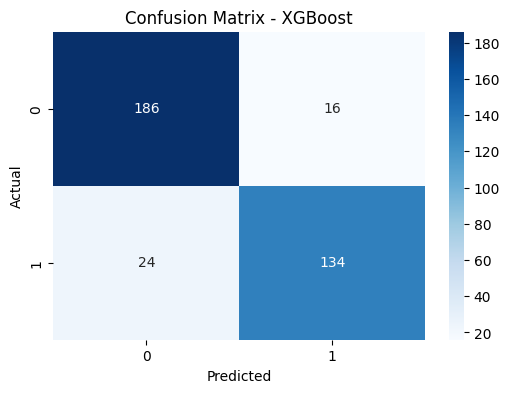

In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred_xgb)
print(cm)
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - XGBoost")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

<Axes: >

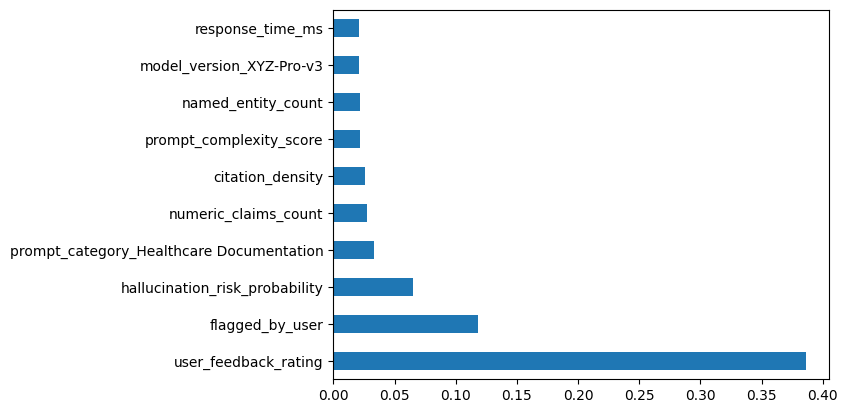

In [64]:
import matplotlib.pyplot as plt

importance = xgb.feature_importances_

feat_imp = pd.Series(
    importance,
    index=X_train_encoded.columns
)

feat_imp.sort_values(
    ascending=False
).head(10).plot(
    kind='barh'
)

In [68]:
from sklearn.metrics import accuracy_score

# Ensure predictions are available in this scope
pred_lr = lr.predict(X_test_scaled)
pred_rf = rf.predict(X_test_scaled)
pred_xgb = xgb.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, pred_lr))

print("Random Forest Accuracy:",
      accuracy_score(y_test, pred_rf))

print("XGBoost Accuracy:",
      accuracy_score(y_test, pred_xgb))

Logistic Regression Accuracy: 0.9
Random Forest Accuracy: 0.8916666666666667
XGBoost Accuracy: 0.8888888888888888


In [70]:
from sklearn.metrics import classification_report

print("XGBoost Classification Report")
print(classification_report(y_test, pred_xgb))

XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.89      0.92      0.90       202
           1       0.89      0.85      0.87       158

    accuracy                           0.89       360
   macro avg       0.89      0.88      0.89       360
weighted avg       0.89      0.89      0.89       360



In [72]:
from sklearn.metrics import roc_auc_score

xgb_prob = xgb.predict_proba(X_test_scaled)[:,1]

auc = roc_auc_score(
    y_test,
    xgb_prob
)

print("ROC AUC Score:", auc)

ROC AUC Score: 0.9516543426494548


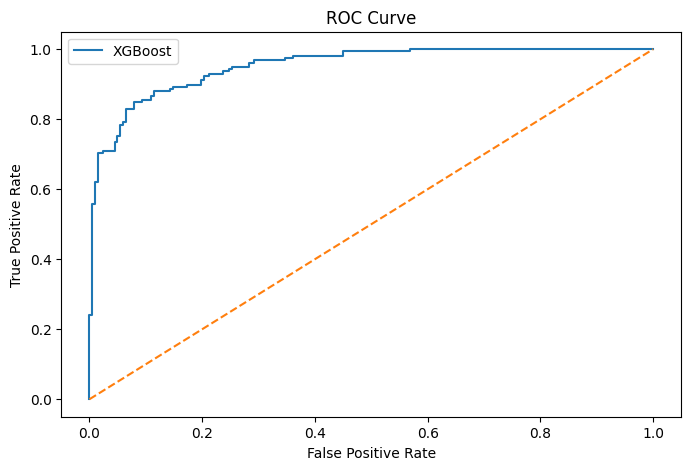

In [73]:
from sklearn.metrics import roc_curve

xgb_prob = xgb.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    xgb_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label='XGBoost'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [75]:
import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[

        accuracy_score(y_test, pred_lr),

        accuracy_score(y_test, pred_rf),

        accuracy_score(y_test, pred_xgb)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.900000
1,Random Forest,0.891667
2,XGBoost,0.888889


In [82]:
feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
11,user_feedback_rating,0.386229
12,flagged_by_user,0.118067
13,hallucination_risk_probability,0.064894
20,prompt_category_Healthcare Documentation,0.032877
7,numeric_claims_count,0.027739
15,citation_density,0.025798
1,prompt_complexity_score,0.022092
9,named_entity_count,0.021888
29,model_version_XYZ-Pro-v3,0.021262
10,response_time_ms,0.021146


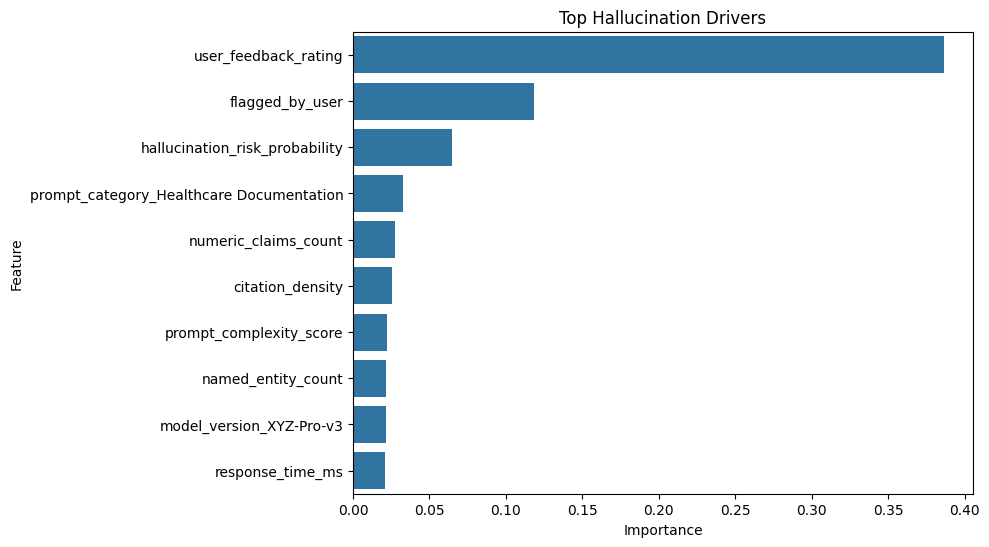

In [83]:
plt.figure(figsize=(8,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=feature_importance.head(10)

)

plt.title(
    "Top Hallucination Drivers"
)

plt.show()

In [88]:
probabilities = xgb.predict_proba(X_test_scaled)

risk_scores = probabilities[:,1]

risk_level = []

for score in risk_scores:

    if score < 0.30:
        risk_level.append("Low Risk")

    elif score < 0.70:
        risk_level.append("Medium Risk")

    else:
        risk_level.append("High Risk")


In [89]:
results = pd.DataFrame({

    'Actual': y_test.values,

    'Risk Score': risk_scores,

    'Risk Level': risk_level

})

results.head(20)

,Actual,Risk Score,Risk Level
0,0,0.553928,Medium Risk
1,1,0.044967,Low Risk
2,0,0.015862,Low Risk
3,1,0.999080,High Risk
4,0,0.000869,Low Risk
5,1,0.999642,High Risk
6,0,0.003592,Low Risk
7,1,0.986467,High Risk
8,1,0.999120,High Risk
9,0,0.353319,Medium Risk
